# Task 4.6

**4.6 Predict antibody breadth - percentage of variants with HAI >= 40 (D28)**
* Training Data: Demographics + Day 0 + Day 7 innate
* Assay: HAI / Measure: Percentage / Metric: Spearman correlation
* Full description: Percentage of variants with HAI >= 40 at Day 28

---

**y-values:** fraction (0–1) of measured variants meeting HAI ≥ 40. HAI values in `hai_cleaned.csv` are log2-transformed, so threshold is `log2(40) ≈ 5.32`.

**5-fold cross-validation:** each participant's prediction is made by a model that never saw them during training.

In [1]:
import os

import joblib
import numpy as np
import pandas as pd

from model_utils import evaluate, predict_challenge

In [2]:
USE_GOOGLE_COLAB = False
HAI_THRESHOLD = 40  # variants with raw HAI >= this value count toward breadth

if USE_GOOGLE_COLAB:
    from google.colab import drive

    drive.mount('/content/drive')
    DATA_PATH = os.path.join(os.getcwd(), 'drive', 'MyDrive', 'DSE_260A', 'data', 'cleaned_data')
else:
    DATA_PATH = '../cleaned_data'

MODEL_PATH = 'models/task_4_6_model.pkl'
SUBMISSION_PATH = 'submission/task_4_6.csv'

In [3]:
train_participants = pd.read_csv(DATA_PATH + '/participants_cleaned.csv')
train_hai = pd.read_csv(DATA_PATH + '/hai_cleaned.csv')

# Data is pre-cleaned: one row per participant, HAI columns as HAI_{strain}_d{timepoint},
# participant columns as PART_{field}.
data = train_hai.merge(train_participants, on='participant_id', how='inner')
part_cols = [c for c in data.columns if c.startswith('PART_')]
print(f'Merged shape: {data.shape}')

# Challenge set: unseen participants we generate final submission predictions for.
challenge_participants = pd.read_csv(DATA_PATH + '/challenge_participants_cleaned.csv')
challenge_hai = pd.read_csv(DATA_PATH + '/challenge_hai_cleaned.csv')
challenge_data = challenge_hai.merge(challenge_participants, on='participant_id', how='inner')
print(f'Challenge shape: {challenge_data.shape}')

Merged shape: (3757, 199)
Challenge shape: (40, 21)


---

## Task 4.6 — Percentage of variants with HAI >= 40 (D28)

Samples: 3705   Features: 72
Spearman (5-fold CV): 0.549  (p-value: 1.505e-290)
Model                                        RMSE        MSE      MAE   Spearman
Linear Regression (5-Fold CV)              0.2751     0.0757   0.2257     0.5488


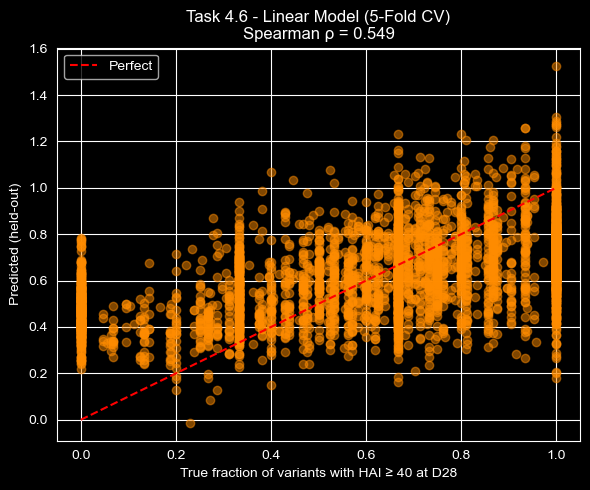

Model saved to models/task_4_6_model.pkl


In [4]:
all_d28_cols = [c for c in data.columns if c.startswith('HAI_') and c.endswith('_d28')]
all_d0_cols = [c for c in data.columns if c.startswith('HAI_') and c.endswith('_d0')]

# HAI values in the cleaned table are log2. Compare against log2(HAI_THRESHOLD).
threshold_log2 = np.log2(HAI_THRESHOLD)

d28_block = data[all_d28_cols]
above = (d28_block >= threshold_log2).sum(axis=1)
measured = d28_block.notna().sum(axis=1)
y_vals = (above / measured).where(measured > 0)

mask = y_vals.notna()
y_vals = y_vals[mask]

feature_cols = all_d0_cols + part_cols
X = data.loc[mask, feature_cols].copy()

y_pred_cv, model = evaluate(X, y_vals, 'Task 4.6', plot_color='darkorange',
                            y_axis_label='True fraction of variants with HAI ≥ 40 at D28')

os.makedirs('models', exist_ok=True)
joblib.dump(model, MODEL_PATH)
print(f'Model saved to {MODEL_PATH}')

In [5]:
y_pred_challenge = predict_challenge(model, challenge_data, feature_cols)

results = pd.DataFrame({
    'Participant_ID': challenge_data['participant_id'].values,
    'Task_4.6': y_pred_challenge,  # already a fraction — no inverse transform needed
})
os.makedirs('submission', exist_ok=True)
results.to_csv(SUBMISSION_PATH, index=False)
results

,Participant_ID,Task_4.6
0,2024_UGA.ID_077,0.690163
1,2024_UGA.ID_086,0.824815
2,2024_UGA.ID_128,0.979425
3,2024_UGA.ID_170,0.651561
4,2024_UGA.ID_179,0.629138
5,2024_UGA.ID_215,0.848773
6,2024_UGA.ID_219,0.821359
7,2024_UGA.ID_275,0.529314
8,2024_UGA.ID_295,0.629828
9,2024_UGA.ID_296,0.594505
